In [2]:
import os
import glob
from PIL import Image
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import numpy as np
import zipfile
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import random
import torch.nn as nn
import torch.nn.functional as F
import sklearn.metrics as metrics
import seaborn as sns

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
gdrive_file_id = '1PCeClx-rhn4QbKi1-XS5UY7JC8iYoA1Q'
output_zip_name = 'train_test_val_dataset.zip'
destination_path = '/content/dataset_images'

print(f"Downloading dataset from Google Drive (ID: {gdrive_file_id})...")
!gdown --id {gdrive_file_id} -O {output_zip_name}
print("Download complete.")

# Check if the zip file exists before proceeding
if os.path.exists(output_zip_name):
    !mkdir -p {destination_path}
    !unzip -q {output_zip_name} -d {destination_path}

    # Define the path to the OxfordPets directory inside destination_path
    oxford_pets_path = os.path.join(destination_path, 'OxfordPets')

    if os.path.exists(oxford_pets_path):
        print(f"Unzipping nested dataset archives in '{oxford_pets_path}'...")

        # Unzip train.zip
        train_zip_path = os.path.join(oxford_pets_path, 'train.zip')
        train_extract_path = os.path.join(oxford_pets_path, 'train')
        if os.path.exists(train_zip_path):
            !mkdir -p {train_extract_path}
            !unzip -q {train_zip_path} -d {train_extract_path}
            print(f"Unzipped {os.path.basename(train_zip_path)} to {train_extract_path}")
        else:
            print(f"Warning: {train_zip_path} not found.")

        # Unzip test.zip
        test_zip_path = os.path.join(oxford_pets_path, 'test.zip')
        test_extract_path = os.path.join(oxford_pets_path, 'test')
        if os.path.exists(test_zip_path):
            !mkdir -p {test_extract_path}
            !unzip -q {test_zip_path} -d {test_extract_path}
            print(f"Unzipped {os.path.basename(test_zip_path)} to {test_extract_path}")
        else:
            print(f"Warning: {test_zip_path} not found.")

        # Unzip valid.zip
        valid_zip_path = os.path.join(oxford_pets_path, 'valid.zip')
        valid_extract_path = os.path.join(oxford_pets_path, 'valid')
        if os.path.exists(valid_zip_path):
            !mkdir -p {valid_extract_path}
            !unzip -q {valid_zip_path} -d {valid_extract_path}
            print(f"Unzipped {os.path.basename(valid_zip_path)} to {valid_extract_path}")
        else:
            print(f"Warning: {valid_zip_path} not found.")

        # Now, set image_dir to the OxfordPets directory and search for images
        image_dir = oxford_pets_path
        image_files = glob.glob(os.path.join(image_dir, '**', '*.jpg'), recursive=True)

        print(f"Found {len(image_files)} image files in '{image_dir}' and its subdirectories after all unzipping.")
    else:
        print(f"Error: 'OxfordPets' directory not found at '{oxford_pets_path}'. Please check the folder structure inside the initial zip.")
else:
    print(f"Error: The downloaded file '{output_zip_name}' was not found. Please ensure the Google Drive ID is correct and the file is accessible.")

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=1PCeClx-rhn4QbKi1-XS5UY7JC8iYoA1Q
From (redirected): https://drive.google.com/uc?id=1PCeClx-rhn4QbKi1-XS5UY7JC8iYoA1Q&confirm=t&uuid=4252d2f5-70f6-471b-8d52-0199b8d58fd3
To: /content/train_test_val_dataset.zip
100% 113M/113M [00:02<00:00, 50.7MB/s]
Download complete.
Unzipping nested dataset archives in '/content/dataset_images/OxfordPets'...
Unzipped train.zip to /content/dataset_images/OxfordPets/train
Unzipped test.zip to /content/dataset_images/OxfordPets/test
Unzipped valid.zip to /content/dataset_images/OxfordPets/valid
Found 3680 image files in '/content/dataset_images/OxfordPets' and its subdirectories after all unzipping.


In [4]:
def parse_annotations_file(annotations_path):
    """Parses an _annotations.txt file and returns a dictionary of image_filename: label."""
    labels = {}
    if not os.path.exists(annotations_path):
        print(f"Warning: Annotations file not found at {annotations_path}")
        return labels

    with open(annotations_path, 'r') as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) > 1:
                image_filename = parts[0]
                # The last column contains bounding box coordinates and the class ID,
                # e.g., 'xmin,ymin,xmax,ymax,class_id'.
                # We need to split this string by comma and take the last element.
                bounding_box_and_label_str = parts[-1]
                label_parts = bounding_box_and_label_str.split(',')
                label = int(label_parts[-1]) # This should be the class ID (0 or 1)
                labels[image_filename] = label
    return labels

# Define paths to the annotation files
# Note: The structure seems to be oxford_pets_path/train/train/_annotations.txt
train_annotations_path = os.path.join(oxford_pets_path, 'train', 'train', '_annotations.txt')
valid_annotations_path = os.path.join(oxford_pets_path, 'valid', 'valid', '_annotations.txt')
test_annotations_path = os.path.join(oxford_pets_path, 'test', 'test', '_annotations.txt')

# Parse annotations for each set
train_labels = parse_annotations_file(train_annotations_path)
valid_labels = parse_annotations_file(valid_annotations_path)
test_labels = parse_annotations_file(test_annotations_path)

print(f"Found {len(train_labels)} training image labels.")
print(f"Found {len(valid_labels)} validation image labels.")
print(f"Found {len(test_labels)} test image labels.")

# Define the class mapping
class_mapping = {0: 'cat', 1: 'dog'}
print(f"\nClass mapping: {class_mapping}")

# Example of how to access a label (if needed later):
# For an image 'some_image.jpg' in the training set:
# label_for_image = train_labels.get('some_image.jpg')
# print(f"Label for some_image.jpg (example): {label_for_image}")

Found 2576 training image labels.
Found 736 validation image labels.
Found 368 test image labels.

Class mapping: {0: 'cat', 1: 'dog'}


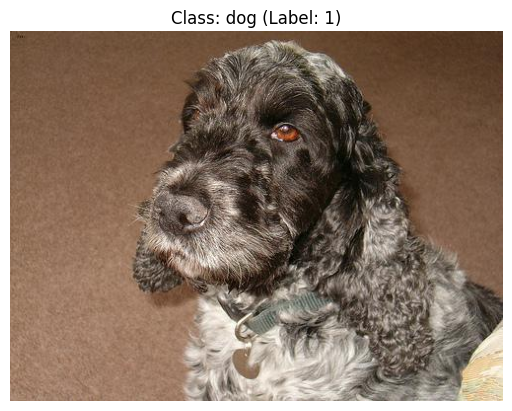

In [5]:
def display_random_train_image():
    """Displays a random image from the training set along with its class label."""
    if not train_labels:
        print("No training labels found. Please ensure annotations are loaded.")
        return

    # Get a list of all image filenames in the training labels
    train_image_filenames = list(train_labels.keys())

    # Select a random image filename
    random_filename = random.choice(train_image_filenames)

    # Construct the full path to the image
    # Assuming the images are in oxford_pets_path/train/train/image.jpg
    image_path = os.path.join(oxford_pets_path, 'train', 'train', random_filename)

    if not os.path.exists(image_path):
        print(f"Image not found at {image_path}. Skipping.")
        return

    # Load the image
    image = Image.open(image_path)

    # Get the numerical label and map it to its class name
    numerical_label = train_labels[random_filename]
    class_name = class_mapping[numerical_label]

    # Display the image and label
    plt.imshow(image)
    plt.title(f"Class: {class_name} (Label: {numerical_label})")
    plt.axis('off')
    plt.show()

display_random_train_image()

In [6]:
import torchvision

class ResNet34BinaryClassifier(torch.nn.Module):
    def __init__(self, num_classes=2):
        super(ResNet34BinaryClassifier, self).__init__()
        # Load a pre-trained ResNet-34 model
        self.resnet = torchvision.models.resnet34(pretrained=True)

        # Freeze all parameters in the feature extractor
        for param in self.resnet.parameters():
            param.requires_grad = False

        # Replace the original fully connected layer (classification head)
        # The original ResNet-34 has a final FC layer with 512 input features.
        num_ftrs = self.resnet.fc.in_features
        self.resnet.fc = torch.nn.Linear(num_ftrs, num_classes)

    def forward(self, x):
        return self.resnet(x)


In [7]:
model = ResNet34BinaryClassifier(num_classes=len(class_mapping))
model.eval() # Set the model to evaluation mode

def visualize_filters(model_instance, layer_idx=None, kernel_idx=None):
    """
    Visualizes a filter (kernel) from a convolutional layer of the model.

    Args:
        model_instance (torch.nn.Module): The PyTorch model instance.
        layer_idx (int, optional): The index of the convolutional layer to visualize.
                                   If None, a random convolutional layer is chosen.
        kernel_idx (int, optional): The index of the kernel (output channel) to visualize
                                    within the selected convolutional layer. If None,
                                    a random kernel is chosen.
    """
    conv_layers = []
    for name, module in model_instance.resnet.named_modules():
        if isinstance(module, nn.Conv2d):
            conv_layers.append((name, module))

    if not conv_layers:
        print("No convolutional layers found in the model.")
        return

    # Select a layer
    if layer_idx is None:
        layer_idx = random.randint(0, len(conv_layers) - 1)
        selected_layer_name, selected_layer = conv_layers[layer_idx]
        print(f"Randomly selected layer: '{selected_layer_name}' (index: {layer_idx})")
    else:
        if not (0 <= layer_idx < len(conv_layers)):
            print(f"Invalid layer_idx: {layer_idx}. Must be between 0 and {len(conv_layers) - 1}.")
            return
        selected_layer_name, selected_layer = conv_layers[layer_idx]

    weights = selected_layer.weight.data.cpu().numpy() # (out_channels, in_channels, kernel_height, kernel_width)

    # Select a kernel
    if kernel_idx is None:
        kernel_idx = random.randint(0, weights.shape[0] - 1) # out_channels
        print(f"Randomly selected kernel: {kernel_idx}")
    else:
        if not (0 <= kernel_idx < weights.shape[0]):
            print(f"Invalid kernel_idx: {kernel_idx}. Must be between 0 and {weights.shape[0] - 1} for layer '{selected_layer_name}'.")
            return

    # Extract the selected kernel's weights
    kernel_weights = weights[kernel_idx] # (in_channels, kernel_height, kernel_width)

    fig, ax = plt.subplots(1, 1, figsize=(4, 4))

    if kernel_weights.shape[0] == 3: # If it's a 3-channel input filter (e.g., first conv layer)
        # Transpose to (height, width, channels) for imshow
        img_to_show = np.transpose(kernel_weights, (1, 2, 0))
        # Normalize each channel independently to [0, 1] for display
        img_to_show = (img_to_show - img_to_show.min()) / (img_to_show.max() - img_to_show.min() + 1e-8)
        ax.imshow(img_to_show)
        ax.set_title(f"Layer: {selected_layer_name}, Kernel: {kernel_idx} (RGB-like)")
    else: # For layers with more or fewer than 3 input channels, visualize the first input channel
        filter_slice = kernel_weights[0] # Take the first input channel's weights
        # Normalize for visualization to [0, 1]
        filter_min = filter_slice.min()
        filter_max = filter_slice.max()
        normalized_filter = (filter_slice - filter_min) / (filter_max - filter_min + 1e-8)
        ax.imshow(normalized_filter, cmap='gray')
        ax.set_title(f"Layer: {selected_layer_name}, Kernel: {kernel_idx} (Input Channel 0)")

    ax.axis('off')
    plt.tight_layout()
    plt.show()

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet34_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet34_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet34-b627a593.pth" to /root/.cache/torch/hub/checkpoints/resnet34-b627a593.pth


100%|██████████| 83.3M/83.3M [00:00<00:00, 189MB/s]


Randomly selected layer: 'layer4.2.conv2' (index: 35)
Randomly selected kernel: 372


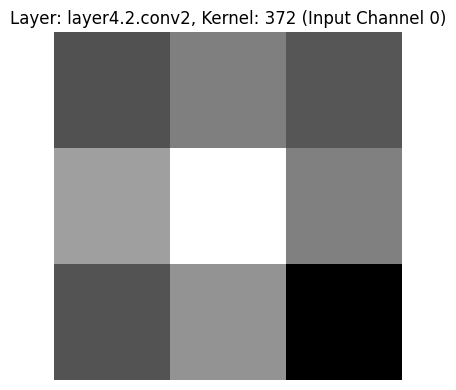

In [8]:
# Example usage: Visualize a random filter
visualize_filters(model)
# visualize_filters(model, layer_idx=1, kernel_idx=3)
# visualize_filters(model, layer_idx=20, kernel_idx=2)


In [9]:
import torchvision.transforms as transforms
import random
import os
from PIL import Image
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import numpy as np

def visualize_feature_map(model_instance, image_path=None):
    """
    Shows an input image and a feature map from a randomly chosen convolutional layer
    in the network.

    Args:
        model_instance (torch.nn.Module): The PyTorch model instance.
        image_path (str, optional): Path to the input image. If None, a random
                                    training image from the dataset will be used.
    """
    # 1. Image Preprocessing
    preprocess = transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])

    if image_path is None:
        if not train_labels:
            print("No training labels found. Cannot select a random image.")
            return
        train_image_filenames = list(train_labels.keys())
        random_filename = random.choice(train_image_filenames)
        image_path = os.path.join(oxford_pets_path, 'train', 'train', random_filename)
        print(f"Randomly selected image: {random_filename}")

    if not os.path.exists(image_path):
        print(f"Error: Image not found at {image_path}")
        return

    original_image = Image.open(image_path).convert('RGB')
    input_tensor = preprocess(original_image)
    input_batch = input_tensor.unsqueeze(0) # create a mini-batch as expected by the model

    # Ensure model is in evaluation mode
    model_instance.eval()

    # 2. Select a random convolutional layer for feature map extraction
    conv_layers = []
    for name, module in model_instance.resnet.named_modules():
        if isinstance(module, nn.Conv2d):
            # Target layers within ResNet's main blocks (layer1, layer2, etc.)
            if any(block_name in name for block_name in ['layer1', 'layer2', 'layer3', 'layer4']):
                conv_layers.append((name, module))

    if not conv_layers:
        print("No suitable convolutional layers found for feature map visualization.")
        return

    selected_layer_name, selected_layer = random.choice(conv_layers)
    print(f"Randomly chosen layer for feature map: '{selected_layer_name}'")

    # 3. Register a hook to capture the output (feature map) of the selected layer
    activations = {}
    def get_activation(name):
        def hook(model, input, output):
            activations[name] = output.detach()
        return hook

    hook_handle = selected_layer.register_forward_hook(get_activation(selected_layer_name))

    # 4. Perform forward pass
    with torch.no_grad():
        _ = model_instance(input_batch)

    # 5. Extract and process the feature map
    feature_map = activations[selected_layer_name].squeeze(0).cpu().numpy()

    # Process feature map for visualization: sum absolute values across channels
    # This gives a single grayscale image representing activation strength,
    # often highlighting edges and textures.
    feature_map_display = np.sum(np.abs(feature_map), axis=0)

    # Normalize to [0, 1] for display
    feature_map_min = feature_map_display.min()
    feature_map_max = feature_map_display.max()
    if feature_map_max - feature_map_min > 1e-8:
        feature_map_display = (feature_map_display - feature_map_min) / (feature_map_max - feature_map_min)
    else:
        feature_map_display = np.zeros_like(feature_map_display)

    # 6. Remove the hook
    hook_handle.remove()

    # 7. Visualization
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))

    axes[0].imshow(original_image)
    axes[0].set_title("Input Image")
    axes[0].axis('off')

    # Use 'viridis' cmap for better contrast and 'bilinear' interpolation for smoother appearance
    axes[1].imshow(feature_map_display, cmap='viridis', interpolation='bilinear')
    axes[1].set_title(f"Feature Map from '{selected_layer_name}'")
    axes[1].axis('off')

    plt.tight_layout()
    plt.show()


Randomly selected image: Birman_12_jpg.rf.47f8d3b92bbb7360d0baa96a06017be6.jpg
Randomly chosen layer for feature map: 'layer2.0.downsample.0'


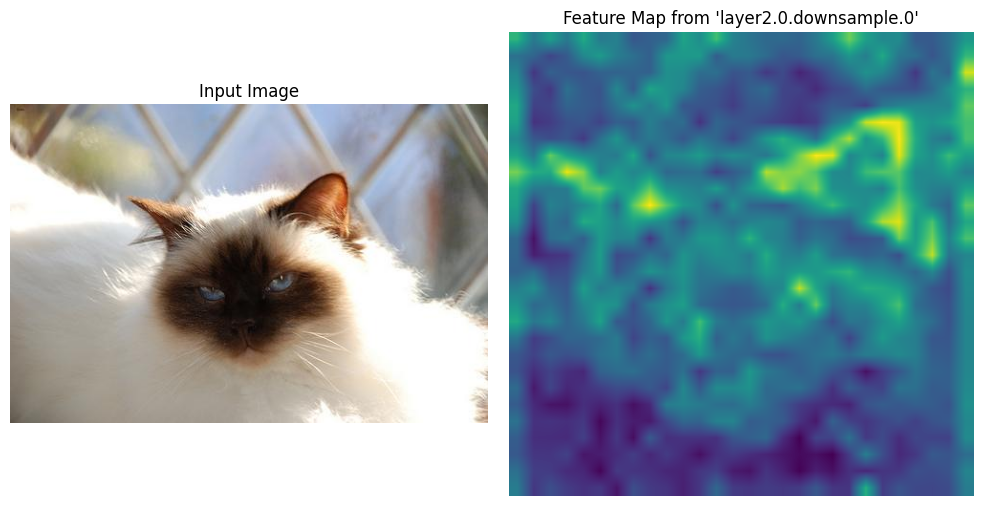

In [10]:
# Call the function to demonstrate
visualize_feature_map(model)

In [11]:
class ImageDataset(Dataset):
    def __init__(self, image_dir, labels, transform=None):
        self.image_dir = image_dir
        self.labels = labels
        self.transform = transform
        self.image_filenames = list(labels.keys())

    def __len__(self):
        return len(self.image_filenames)

    def __getitem__(self, idx):
        img_name = self.image_filenames[idx]
        img_path = os.path.join(self.image_dir, img_name)
        image = Image.open(img_path).convert('RGB')
        label = self.labels[img_name]

        if self.transform:
            image = self.transform(image)

        return image, label

# Define transforms for training and validation
train_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.RandomCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

val_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# Create datasets
train_dataset = ImageDataset(
    image_dir=os.path.join(oxford_pets_path, 'train', 'train'),
    labels=train_labels,
    transform=train_transform
)

val_dataset = ImageDataset(
    image_dir=os.path.join(oxford_pets_path, 'valid', 'valid'),
    labels=valid_labels,
    transform=val_transform
)

# Create DataLoaders
batch_size = 32 # You can adjust this
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

# Move model to GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# Define loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# Training loop
num_epochs = 10 # You can adjust this

print("Starting training...")
for epoch in range(num_epochs):
    model.train() # Set model to training mode
    running_train_loss = 0.0
    correct_train_predictions = 0
    total_train_predictions = 0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()

        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_train_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs.data, 1)
        total_train_predictions += labels.size(0)
        correct_train_predictions += (predicted == labels).sum().item()

    epoch_train_loss = running_train_loss / len(train_dataset)
    epoch_train_accuracy = correct_train_predictions / total_train_predictions

    # Validation phase
    model.eval() # Set model to evaluation mode
    running_val_loss = 0.0
    correct_val_predictions = 0
    total_val_predictions = 0

    with torch.no_grad(): # Disable gradient calculations during validation
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            outputs = model(inputs)
            loss = criterion(outputs, labels)

            running_val_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs.data, 1)
            total_val_predictions += labels.size(0)
            correct_val_predictions += (predicted == labels).sum().item()

    epoch_val_loss = running_val_loss / len(val_dataset)
    epoch_val_accuracy = correct_val_predictions / total_val_predictions

    print(f"Epoch {epoch+1}/{num_epochs}: ")
    print(f"  Train Loss: {epoch_train_loss:.4f}, Train Accuracy: {epoch_train_accuracy:.4f}")
    print(f"  Validation Loss: {epoch_val_loss:.4f}, Validation Accuracy: {epoch_val_accuracy:.4f}")

print("Training complete!")

Starting training...
Epoch 1/10: 
  Train Loss: 0.2176, Train Accuracy: 0.9231
  Validation Loss: 0.0806, Validation Accuracy: 0.9783
Epoch 2/10: 
  Train Loss: 0.0857, Train Accuracy: 0.9759
  Validation Loss: 0.0508, Validation Accuracy: 0.9864
Epoch 3/10: 
  Train Loss: 0.0743, Train Accuracy: 0.9755
  Validation Loss: 0.0406, Validation Accuracy: 0.9878
Epoch 4/10: 
  Train Loss: 0.0671, Train Accuracy: 0.9786
  Validation Loss: 0.0331, Validation Accuracy: 0.9891
Epoch 5/10: 
  Train Loss: 0.0615, Train Accuracy: 0.9779
  Validation Loss: 0.0426, Validation Accuracy: 0.9837
Epoch 6/10: 
  Train Loss: 0.0511, Train Accuracy: 0.9810
  Validation Loss: 0.0350, Validation Accuracy: 0.9851
Epoch 7/10: 
  Train Loss: 0.0602, Train Accuracy: 0.9775
  Validation Loss: 0.0275, Validation Accuracy: 0.9891
Epoch 8/10: 
  Train Loss: 0.0551, Train Accuracy: 0.9775
  Validation Loss: 0.0390, Validation Accuracy: 0.9837
Epoch 9/10: 
  Train Loss: 0.0483, Train Accuracy: 0.9833
  Validation Loss

Test Accuracy: 0.9946


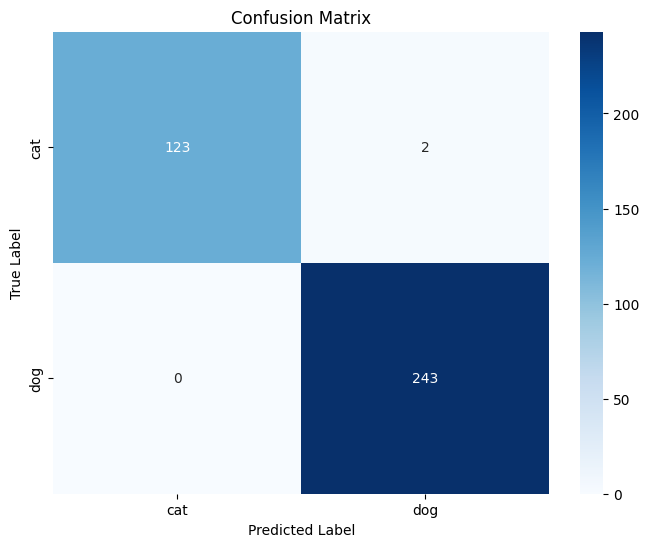

In [12]:
# Define transforms for the test set (similar to validation set)
test_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# Create test dataset
test_dataset = ImageDataset(
    image_dir=os.path.join(oxford_pets_path, 'test', 'test'),
    labels=test_labels,
    transform=test_transform
)

# Create Test DataLoader
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

# Set model to evaluation mode
model.eval()

all_preds = []
all_labels = []
correct_test_predictions = 0
total_test_predictions = 0

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        outputs = model(inputs)
        _, predicted = torch.max(outputs.data, 1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

        total_test_predictions += labels.size(0)
        correct_test_predictions += (predicted == labels).sum().item()

test_accuracy = correct_test_predictions / total_test_predictions
print(f"Test Accuracy: {test_accuracy:.4f}")

# Generate Confusion Matrix
cm = metrics.confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_mapping.values(), yticklabels=class_mapping.values())
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

Found 2 misclassified images.


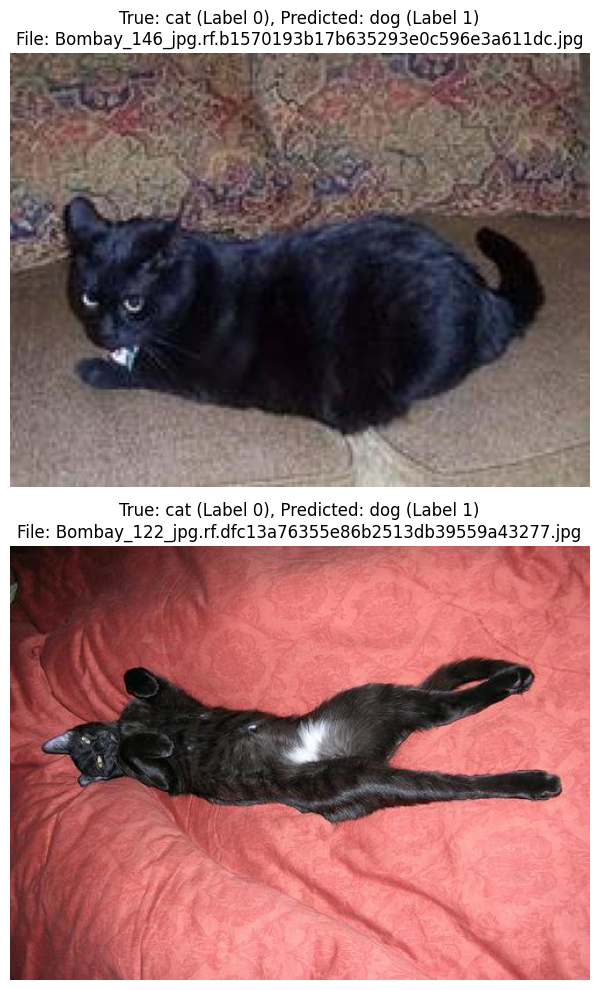

In [13]:
misclassified_indices = []
for i in range(len(all_labels)):
    if all_labels[i] != all_preds[i]:
        misclassified_indices.append(i)

print(f"Found {len(misclassified_indices)} misclassified images.")

if not misclassified_indices:
    print("No misclassified images to display!")
else:
    plt.figure(figsize=(10, 5 * len(misclassified_indices)))
    for i, idx in enumerate(misclassified_indices):
        # Get original image details from test_dataset
        img_name = test_dataset.image_filenames[idx]
        img_path = os.path.join(test_dataset.image_dir, img_name)
        original_image = Image.open(img_path).convert('RGB')

        true_label = all_labels[idx]
        predicted_label = all_preds[idx]

        plt.subplot(len(misclassified_indices), 1, i + 1)
        plt.imshow(original_image)
        plt.title(f"True: {class_mapping[true_label]} (Label {true_label}), Predicted: {class_mapping[predicted_label]} (Label {predicted_label})\nFile: {img_name}")
        plt.axis('off')
    plt.tight_layout()
    plt.show()